# Session 18: Data Visualization

By: Viktoria Haghani

Session Date: TBD

Last Updated: 2026-03-12

Reference materials include teaching material from Dr. Nick Ulle.

In [1]:
# Import
import polars as pl
import matplotlib.pyplot as plt
import pyarrow

# Read in data
terns = pl.read_csv("../Session_16/2000-2023_ca_least_tern.csv")

After this lesson, you should be able to:

* List and describe popular data visualization packages
* Prepare data for visualization
* Describe the grammar of graphics
* Use the grammar of graphics to produce a plot
* Identify where to go to learn more about making effective visualizations
* Compute aggregates of data
* Split data into groups and compute aggregates on each

Now that you have a solid foundation in the basic functions and data structures
of Python, you can move on to using it for data analysis. In this chapter,
you'll learn how to efficiently explore and summarize with visualizations and
statistics.

## Visualization Packages

![A network of Python visualization packages](https://ucdavisdatalab.github.io/workshop_python_basics/_images/visualization_landscape.png)

*Fig. 3.1* Image from [Jake VanderPlas][jake]. See [here][viz] for a version with links
to all of the packages!

[jake]: http://vanderplas.com/
[viz]: https://rougier.github.io/python-visualization-landscape/landscape-colors.html

A visualization is one of the most effective ways to display and summarize
data, and there are many ways to create visualizations in Python. In fact, so
many visualization packages are available that there's even [a website][pyviz]
dedicated to helping people decide which to use. Some popular packages for
creating static visualizations are:

[pyviz]: https://pyviz.org/

* [Matplotlib][] is the foundation for most other visualization packages.
  Matplotlib is low-level, meaning it's flexible but even simple plots may take
  [5 lines of code or more][viz-pkg-tour]. It's good to know a little bit about
  Matplotlib, but it probably shouldn't be your primary visualization package.
  Familiarity with MATLAB makes it easier to learn Matplotlib.

* [Plotnine][] is a copy of the popular R package [ggplot2][]. The package uses
  the **grammar of graphics**, a convenient way to describe visualizations in
  terms of layers. Familiarity with ggplot2 or Julia's [Gadfly.jl][] package
  makes it easier to learn Plotnine (and vice-versa).

* [Seaborn][] is designed specifically for making statistical plots. It's
  well-documented and stable.

* Polars provides [built-in plotting functions][pl-plot] based on [Altair][],
  which can be convenient but are more limited than what you'll find in
  dedicated visualization packages.

[Matplotlib]: https://matplotlib.org/
[viz-pkg-tour]: https://dsaber.com/2016/10/02/a-dramatic-tour-through-pythons-data-visualization-landscape-including-ggplot-and-altair/
[Plotnine]: https://plotnine.org/
[ggplot2]: https://ggplot2.tidyverse.org/
[Gadfly.jl]: http://gadflyjl.org/stable/
[Seaborn]: https://seaborn.pydata.org/
[pl-plot]: https://docs.pola.rs/user-guide/misc/visualization/
[Altair]: https://altair-viz.github.io/

We'll focus on Plotnine, so that the visualization skills you learn here will
also be relevant if you end up using R or Julia. Plotnine has detailed
[documentation][plotnine-docs]. It's also useful to look at the [ggplot2
documentation][ggplot2] and [cheatsheet][ggplot2-cheat].

[plotnine-docs]: https://plotnine.org/guide/
[ggplot2-cheat]: https://github.com/rstudio/cheatsheets/blob/main/data-visualization-2.1.pdf

## The Grammar of Graphics

Recall that plotnine is a clone of ggplot2. The "gg" in ggplot2 stands for
*grammar of graphics*. The idea of a grammar of graphics is that visualizations
can be built up in layers. The three layers every plot must have are:

* Data: one or more data sets
* Geometry: marks to display data, such as points or lines
* Aesthetics: a specification of which features to display with geometry

There are also several optional layers. Here are a few:

| Layer       | Description                                        |
| :---------- | :------------------------------------------------- |
| scales      | Title, label, and axis value settings              |
| facets      | Side-by-side plots                                 |
| guides      | Axis and legend position settings                  |
| annotations | Shapes that are not mapped to data                 |
| coordinates | Coordinate systems (Cartesian, logarithmic, polar) |

Let's visualize the California least terns data set from `sec-hello-data`
to see how the grammar of graphics works in practice. But what kind of plot
should we make? It depends on what we want to know about the data set. Suppose
we want to understand the relationship between the number of breeding pairs and
the total number of nests at each site, and whether this relationship is
affected by climate events. One way to show the relationship between two
numerical features like these is to make a scatter plot.

### Importing Plotnine

Before we can make the plot, we need to import Plotnine.
`sec-importing-modules` explained how to import an entire module  with the
`import` keyword. Python also provides a `from` keyword to import specific
objects from within a module, so that you can access them without the module
name as a prefix.

As an example, Plotnine's `ggplot` function is the starting point for making
plots. You can import the function with `from` like this:

In [2]:
from plotnine import ggplot

Then you can use the function as `ggplot` rather than `plotnine.ggplot`.

You can also use the `from` keyword to import all objects in a module with the
wildcard character `*`. Plotnine is designed to be imported this way:

In [3]:
from plotnine import *

**Caution**: Aside from Plotnine, you generally shouldn't import all objects from a module,
because doing so:

* Makes it harder to understand the code: an object could be defined locally or
  in the module.
* Can introduce bugs: objects from the module will overwrite objects in your
  code that have the same name.

One recommendation is that it's fine to use `from` to import classes (with
`TitleCase` names), but you should avoid using it to import functions (with
`snake_case` names). The justification is that classes are more likely than
functions to have distinct, memorable names.

If you prefer not to use `from` to import functions from Plotnine, you can use
the following convention instead:

```python
import plotnine as p9
```

**Plotting in Jupyter**: Jupyter notebooks can display most static visualizations and some interactive
visualizations. For visualization packages that depend on Matplotlib, it's a
good idea to set the default size of the plots:

```python
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [10, 8]
```

You can increase the numbers to make plots larger, or decrease them to make
plots smaller. Plotnine provides another way to set the plot size through its
theme layer.

In older versions of Jupyter and IPython, it was also necessary to run the
special IPython command `%matplotlib inline` to set up a notebook for plotting.
This is no longer necessary in modern versions, but you may still see people
use or mention it online. You can read more about this change in [this
StackOverflow question][so-mpl-inline].

[so-mpl-inline]: https://stackoverflow.com/questions/65934740/is-matplotlib-inline-still-needed

In [4]:
import plotnine as p9
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [10, 8]

### Layer 1: Data

The **data layer** determines the data set(s) used to make the plot.

Plotnine is designed to work with **tidy** data, which means:

1. Each feature has its own column.
2. Each observation has its own row.
3. Each value has its own cell.

These rules ensure data are easy to read visually and access with indexing. The
least terns data set satisfies all of these rules.

**See Also**: All of the data sets we use in this reader are tidy. To learn how to tidy an
untidy data set, see the [Untidy & Relational Data][dl-py-tidy] chapter of
DataLab's Intermediate Python workshop reader.

[dl-py-tidy]: https://ucdavisdatalab.github.io/workshop_intermediate_python/chapters/02_tidy-relational-data.html

To set up the data layer, call the `ggplot` function on a data frame:

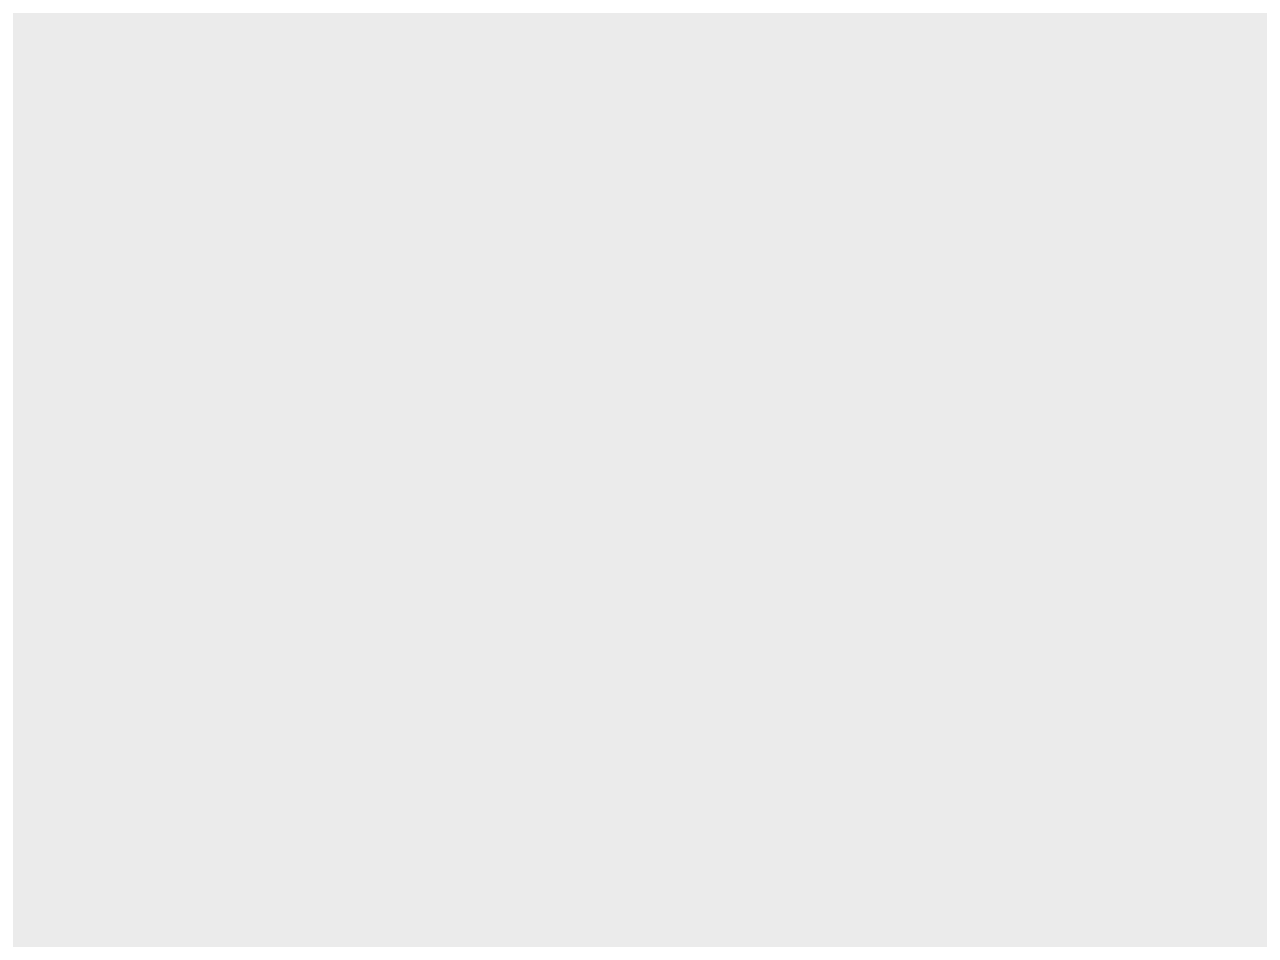

In [5]:
ggplot(terns)

This returns a blank plot. We still need to add a few more layers.

### Layer 2: Geometry

The **geometry layer** determines the shape or appearance of the visual
elements of the plot. In other words, the geometry layer determines what kind
of plot to make: one with points, lines, boxes, or something else.

There are many different geometries available in Plotnine. The package provides
a function for each geometry, always prefixed with `geom_`.

To add a geometry layer to the plot, choose the `geom_` function you want and
add it to the plot with the `+` operator. We'll use `geom_point`, which makes a
scatter plot (a plot with points):

In [6]:
ggplot(terns) + geom_point()

PlotnineError: 'geom_point requires the following missing aesthetics: y, x'

This returns an error message that we're missing aesthetics `x` and `y`. We'll
learn more about aesthetics in the next section, but this error message is
especially helpful: it tells us exactly what we're missing. When you use a
geometry you're unfamiliar with, it can be helpful to run the code for just the
data and geometry layer like this, to see exactly which aesthetics need to be
set.

As we'll see later, it's possible to add multiple geometries to a plot.

### Layer 3: Aesthetics

The **aesthetics layer** determines the relationship between the data and the
geometry. Use the aesthetic layer to map features in the data to aesthetics
(visual elements) of the geometry.

The `aes` function creates an aesthetic layer. The syntax is:

```python
aes(AESTHETIC = FEATURE, ...)
```

The names of the aesthetics depend on the geometry, but some common ones are
`x`, `y`, `color`, `fill`, `shape`, and `size`. There is more information about
and examples of aesthetic names in the documentation.

For the scatter plot of breeding pairs against total nests, we'll put `bp_min`
on the x-axis and `total_nests` on the y-axis. Below, we set both of these
aesthetics. We also enclose all of the code for the plot in parentheses `()` so
that we can put the code for each layer on a separate line, which makes the
layers easier to distinguish:

C:\Users\vicky\Documents\GitHub\my_project\.pixi\envs\default\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 8 rows containing missing values.


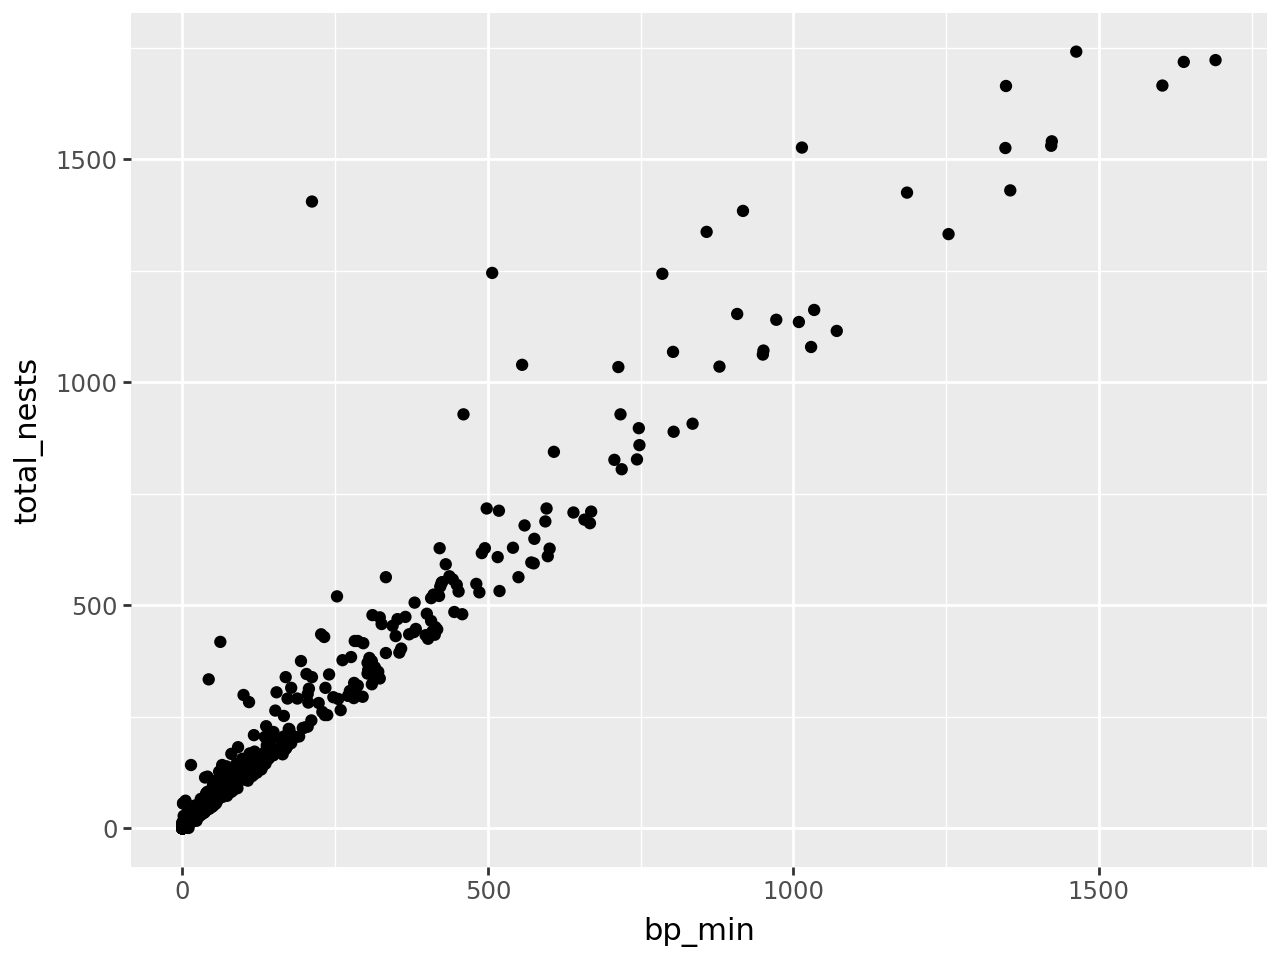

In [7]:
(
    ggplot(terns) +
    aes(x = "bp_min", y = "total_nests") +
    geom_point()
)

At this point, we've supplied all three layers necessary to make a plot: data,
geometry, and aesthetics. The plot shows what looks like a linear relationship
between number of breeding pairs and total nests. To refine the plot, you can
add more layers and/or set parameters on the layers you have.

**Tip**: Python ignores line breaks inside of parentheses `()`, so you can enclose
lengthy expressions in parentheses and format them neatly.

Let's add another aesthetic to the plot: we'll make the color and shape of each
point correspond to `event`, the climate event for each observation:

C:\Users\vicky\Documents\GitHub\my_project\.pixi\envs\default\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 8 rows containing missing values.


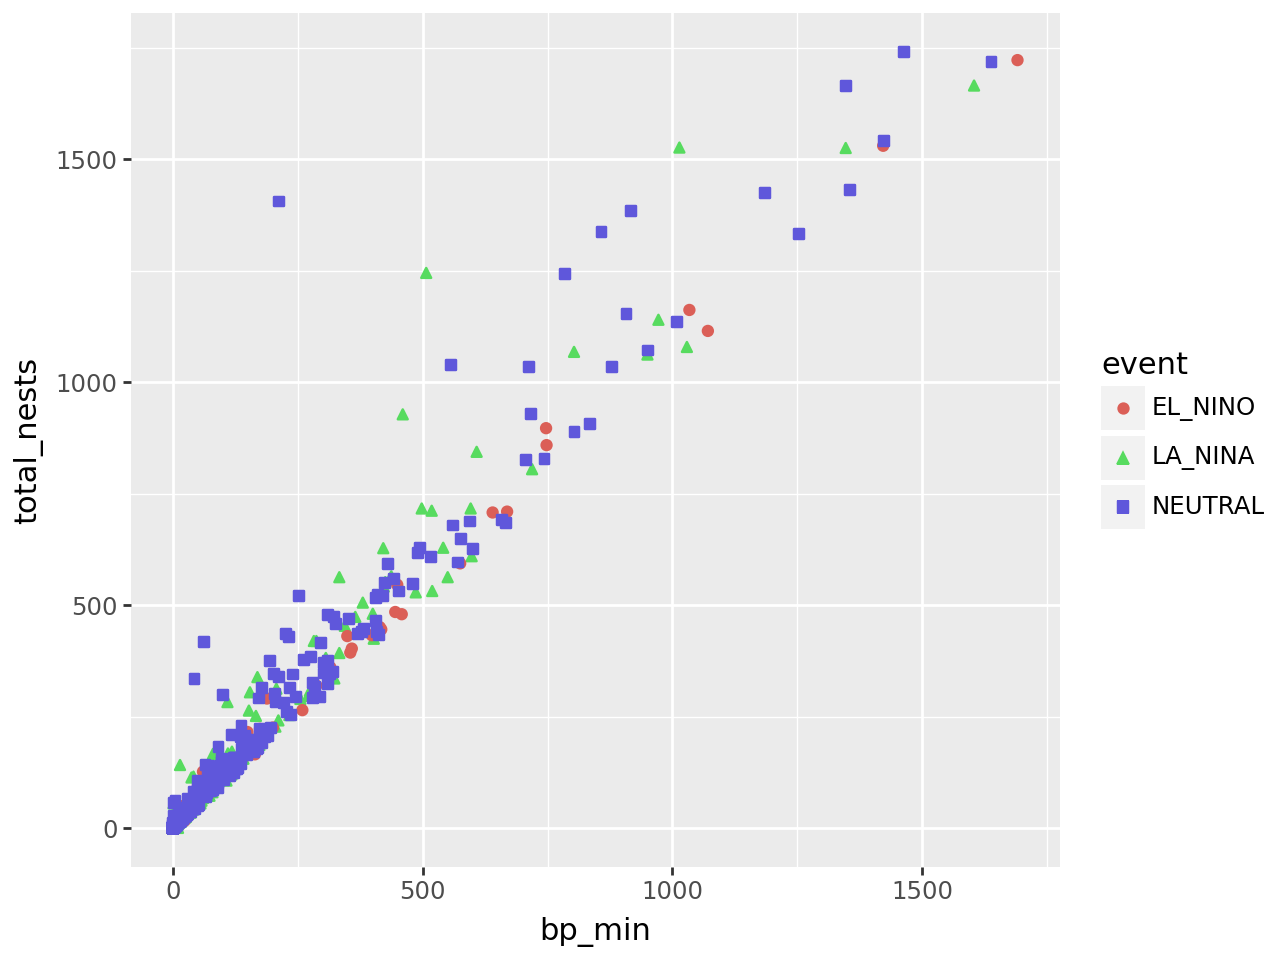

In [8]:
(
    ggplot(terns) +
    aes(x = "bp_min", y = "total_nests", color = "event", shape = "event") +
    geom_point()
)

Using color and shape for the same feature is redundant, but ensures that the
plot is accessible to colorblind people. 

#### Additional Geometries

Each observation in the least terns data corresponds to a specific year and
site. What if we label the points with their years? You can add text labels to
a plot with `geom_text`. The required aesthetic for this geometry is `label`:

C:\Users\vicky\Documents\GitHub\my_project\.pixi\envs\default\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 8 rows containing missing values.
C:\Users\vicky\Documents\GitHub\my_project\.pixi\envs\default\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_text : Removed 8 rows containing missing values.


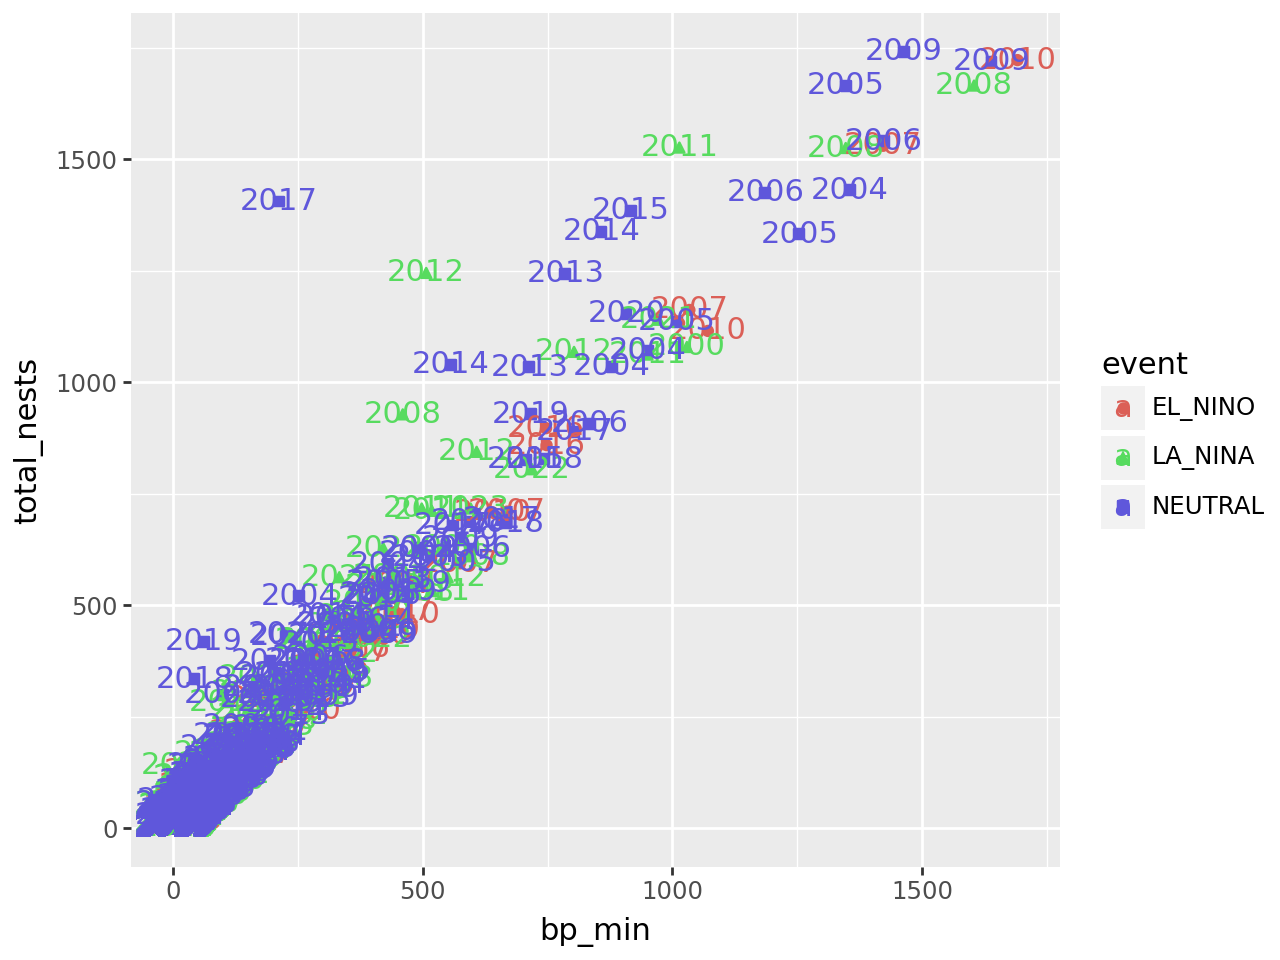

In [9]:
(
    ggplot(terns) +
    aes(
        x = "bp_min", y = "total_nests",
        color = "event", shape = "event",
        label = "year"
    ) +
    geom_point() +
    geom_text()
)

The labels make the plot more difficult to read and probably would even if we
made them smaller, because there are so many points on the plot. Making a
high-quality visualization is typically a process of drafting and revising,
similar to writing a high-quality essay. In this example, adding year labels to
the plot doesn't work well, so we'll backtrack and leave them off of the plot.
If accounting for year was critical to our research question, we could do it in
other ways, such as by making separate plots for each year.

#### Per-geometry Aesthetics

Before we remove the labels, let's use them to demonstrate an important point
about using multiple geometry and aesthetic layers: when you add an aesthetic
layer to a plot, it applies to the entire plot. You can also set an aesthetic
layer for an individual geometry by passing the layer as the first argument in
the `geom_` function. Here's the same plot as above, but with the `color`
aesthetic only set for the labels:

C:\Users\vicky\Documents\GitHub\my_project\.pixi\envs\default\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 8 rows containing missing values.
C:\Users\vicky\Documents\GitHub\my_project\.pixi\envs\default\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_text : Removed 8 rows containing missing values.


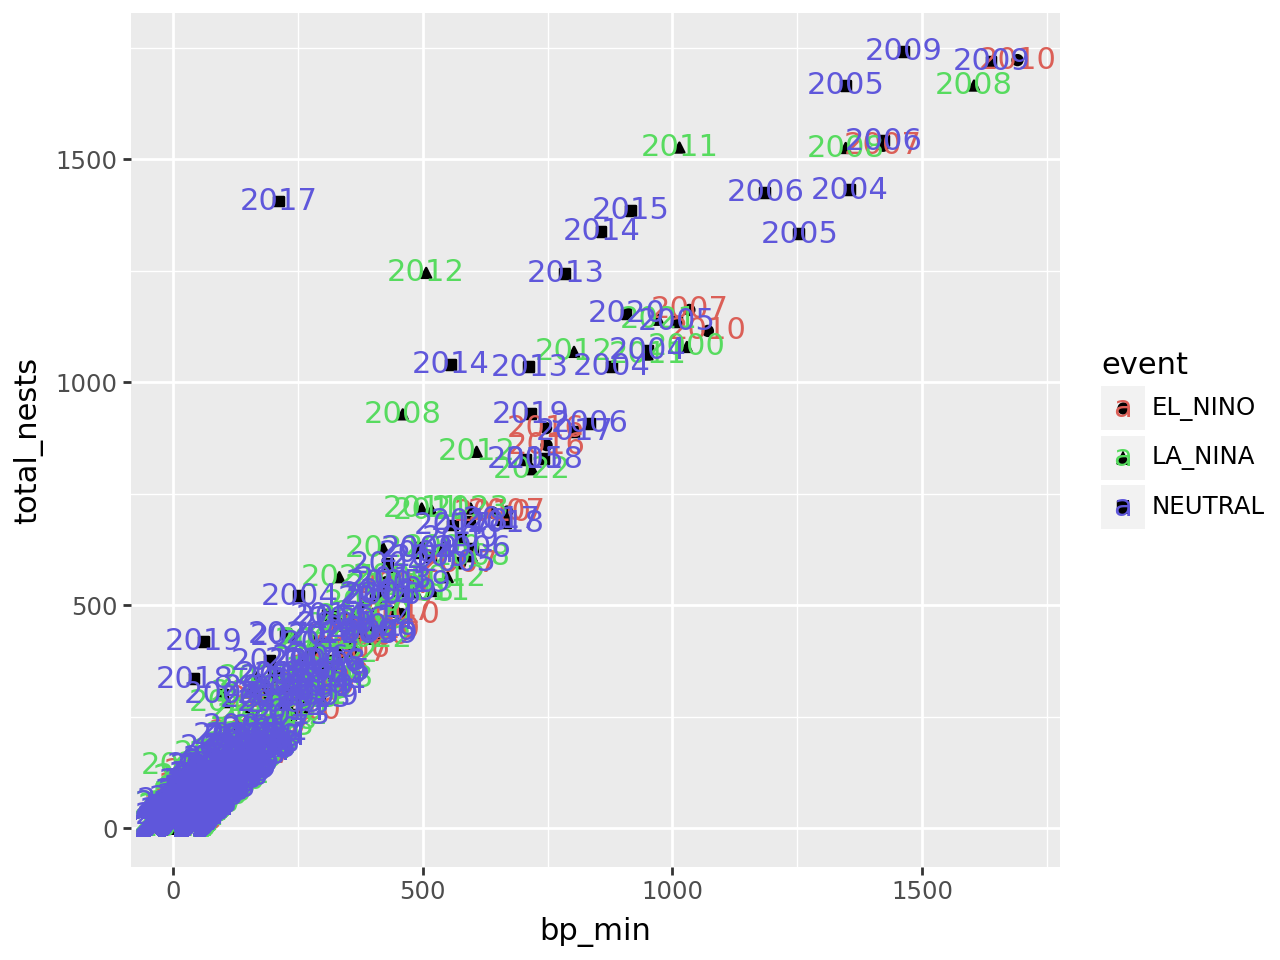

In [10]:
(
    ggplot(terns) +
    aes(
        x = "bp_min", y = "total_nests",
        shape = "event",
        label = "year"
    ) +
    geom_point() +
    geom_text(aes(color = "event"))
)

Notice that the points are no longer color-coded. Where you put aesthetic
layers matters.

#### Constant Aesthetics

If you want to set an aesthetic to a constant value, rather than one that's
data-dependent, do so in the geometry layer rather than the aesthetic layer.

For instance, suppose we want to make all of the points blue and use only point
shape to indicate climate events:

C:\Users\vicky\Documents\GitHub\my_project\.pixi\envs\default\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 8 rows containing missing values.


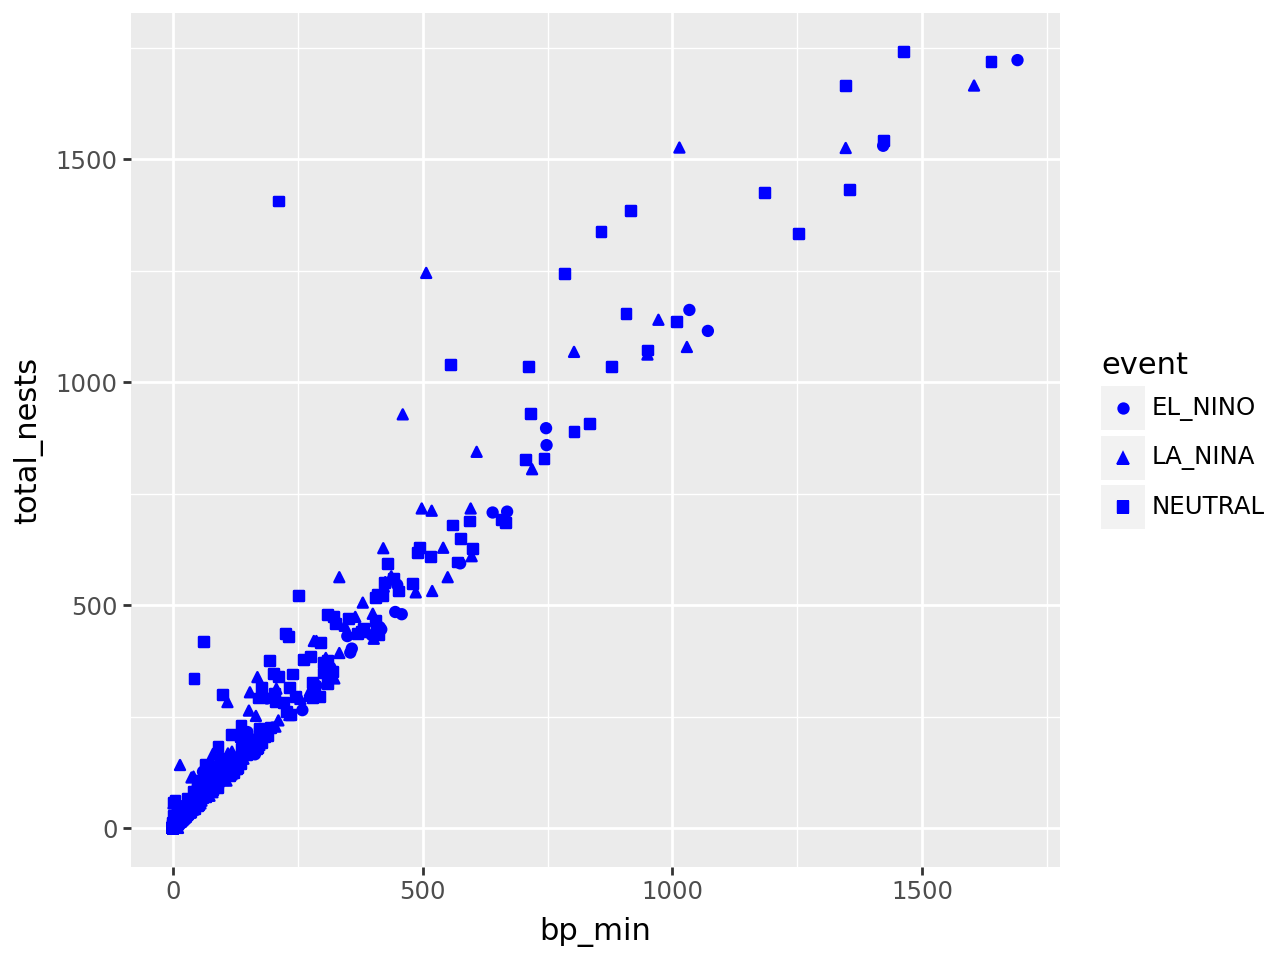

In [11]:
(
    ggplot(terns) +
    aes(
        x = "bp_min", y = "total_nests",
        shape = "event"
    ) +
    geom_point(color = "blue")
)

If you set an aesthetic to a constant value in an aesthetic layer, the results
won't be what you expect:

In [12]:
(
    ggplot(terns) +
    aes(
        x = "bp_min", y = "total_nests",
        color = "blue", shape = "event",
        label = "year"
    ) +
    geom_point() +
    geom_text()
)

PlotnineError: "Could not evaluate the 'color' mapping: 'blue' (original error: name 'blue' is not defined)"

### Layer 4: Scales

The **scales layer** controls the title, axis labels, and axis scales of the
plot. Most of the functions in the scales layer are prefixed with `scale_`, but
not all of them.

The `labs` function is especially important, because it's used to set the title
and axis labels. Visualizations should generally have a title and axis labels,
to aid the viewer:

C:\Users\vicky\Documents\GitHub\my_project\.pixi\envs\default\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 8 rows containing missing values.


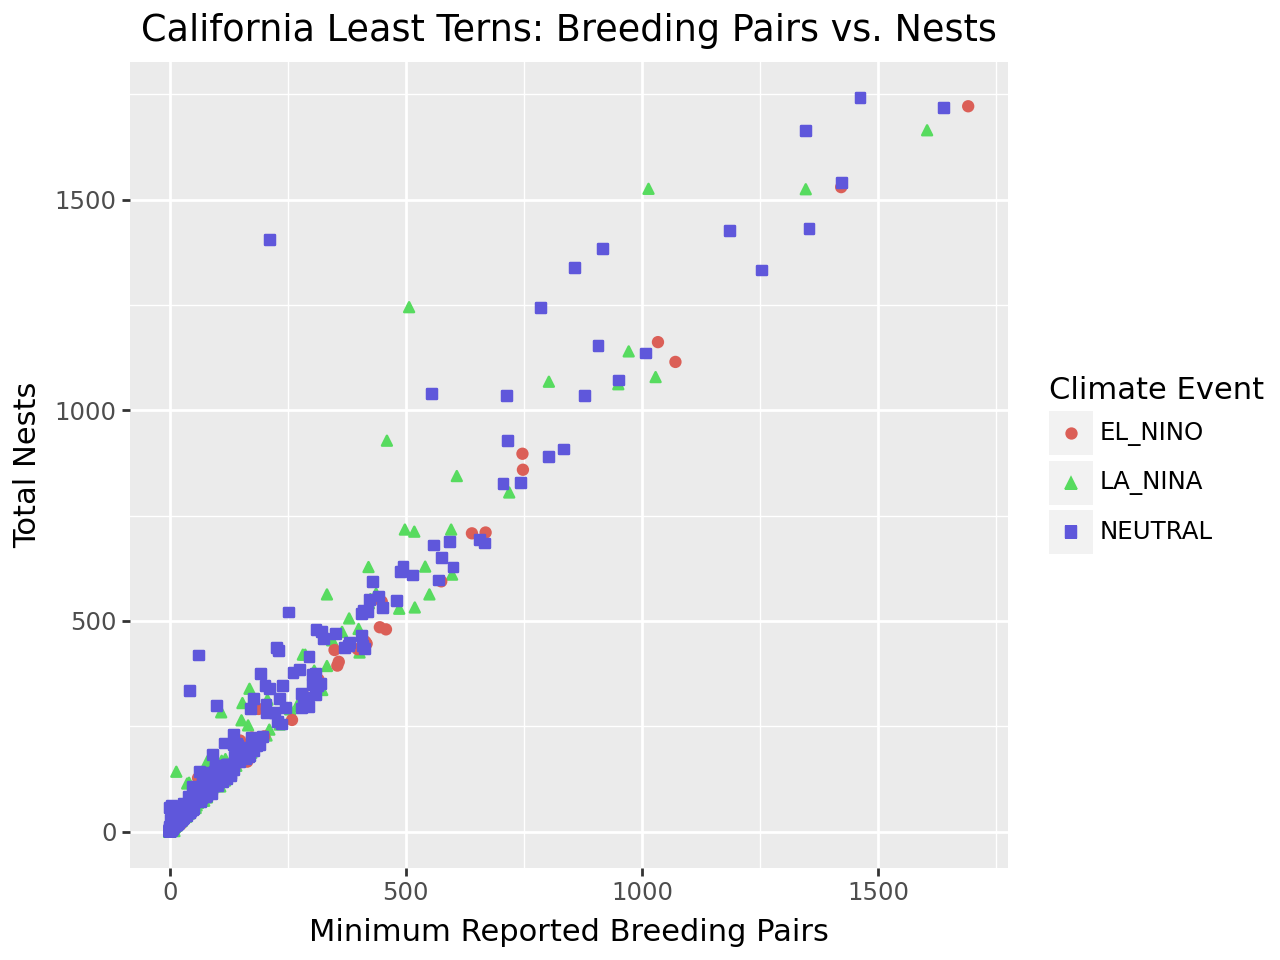

In [13]:
(
    ggplot(terns) +
    aes(
        x = "bp_min", y = "total_nests",
        color = "event", shape = "event"
    ) +
    geom_point() +
    labs(
        x = "Minimum Reported Breeding Pairs",
        y = "Total Nests",
        color = "Climate Event", shape = "Climate Event",
        title = "California Least Terns: Breeding Pairs vs. Nests"
    )
)

Notice that to set the title for a legend with `labs`, you can set the
parameters of the same names as the corresponding aesthetics. While our plot is
still far from perfect---some of the points are hard to see because of how many
there are---it's now good enough to provide some insight into the relationship
between number of breeding pairs and nests.

### Saving Plots

If you assign a plot to a variable, you can use the `save` method or the
`ggsave` function to save that plot to a file:

In [14]:
plot = (
    ggplot(terns) +
    aes(
        x = "bp_min", y = "total_nests",
        color = "event", shape = "event"
    ) +
    geom_point() +
    labs(
        x = "Minimum Reported Breeding Pairs",
        y = "Total Nests",
        color = "Climate Event", shape = "Climate Event",
        title = "California Least Terns: Breeding Pairs vs. Nests"
    )
)

ggsave(plot, "myplot.png")

C:\Users\vicky\Documents\GitHub\my_project\.pixi\envs\default\Lib\site-packages\plotnine\ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
C:\Users\vicky\Documents\GitHub\my_project\.pixi\envs\default\Lib\site-packages\plotnine\ggplot.py:616: PlotnineWarning: Filename: myplot.png
C:\Users\vicky\Documents\GitHub\my_project\.pixi\envs\default\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 8 rows containing missing values.


The file format is selected automatically based on the extension. Common
formats include PNG, TIFF, SVG, and PDF.

**Tip**: PNG and SVG are good choices for sharing visualizations online, while TIFF and
PDF are good choices for print. Many journals require that visualizations be in
TIFF format.

### Example: Bar Plot

Suppose we want to visualize how many fledglings there are each year, further
broken down by region. A bar plot is one appropriate way to represent this
visually.

The geometry for a bar plot is `geom_bar`. Since bar plots are mainly used to
display frequencies, by default the `geom_bar` function counts the number of
observations in each category on the x-axis and displays these counts on the
y-axis. You can make `geom_bar` display values from a column on the y-axis by
setting the `weight` aesthetic:

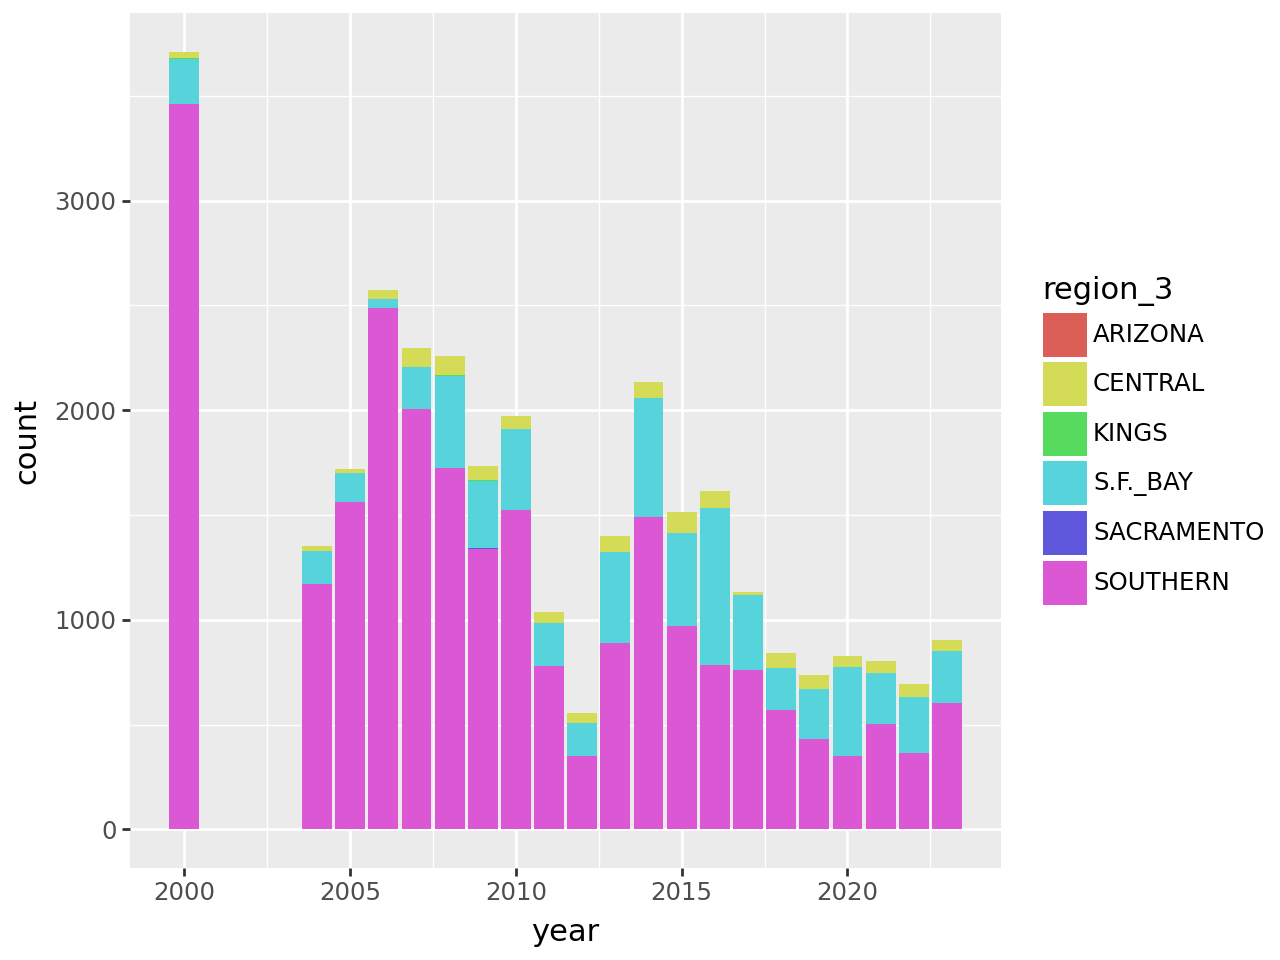

In [15]:
(
    ggplot(terns) +
    aes(x = "year", weight = "fl_min", fill = "region_3") +
    geom_bar()
)

**Setting the Statistics Layer**: Every geometry layer has a corresponding statistics layer, which transforms
feature values into quantities to plot. For many geometries, the default
statistics layer is the only one that makes sense.

Bar plots are an exception. The default statistics layer is `stat_count`, which
counts observations. If you already have counts (or just want to display some
quantities as bars), you need `stat_identity` (or the `weight` aesthetic
described above). Here's one way to change the statistics layer:

```python
(
    ggplot(terns) +
    aes(x = "year", y = "fl_min", fill = "region_3") +
    geom_bar(stat = "identity")
)
```

This produces the same plot as setting `weight` and using the default
statistics layer `stat_count`.

C:\Users\vicky\Documents\GitHub\my_project\.pixi\envs\default\Lib\site-packages\plotnine\layer.py:344: PlotnineWarning: position_stack : Removed 12 rows containing missing values.


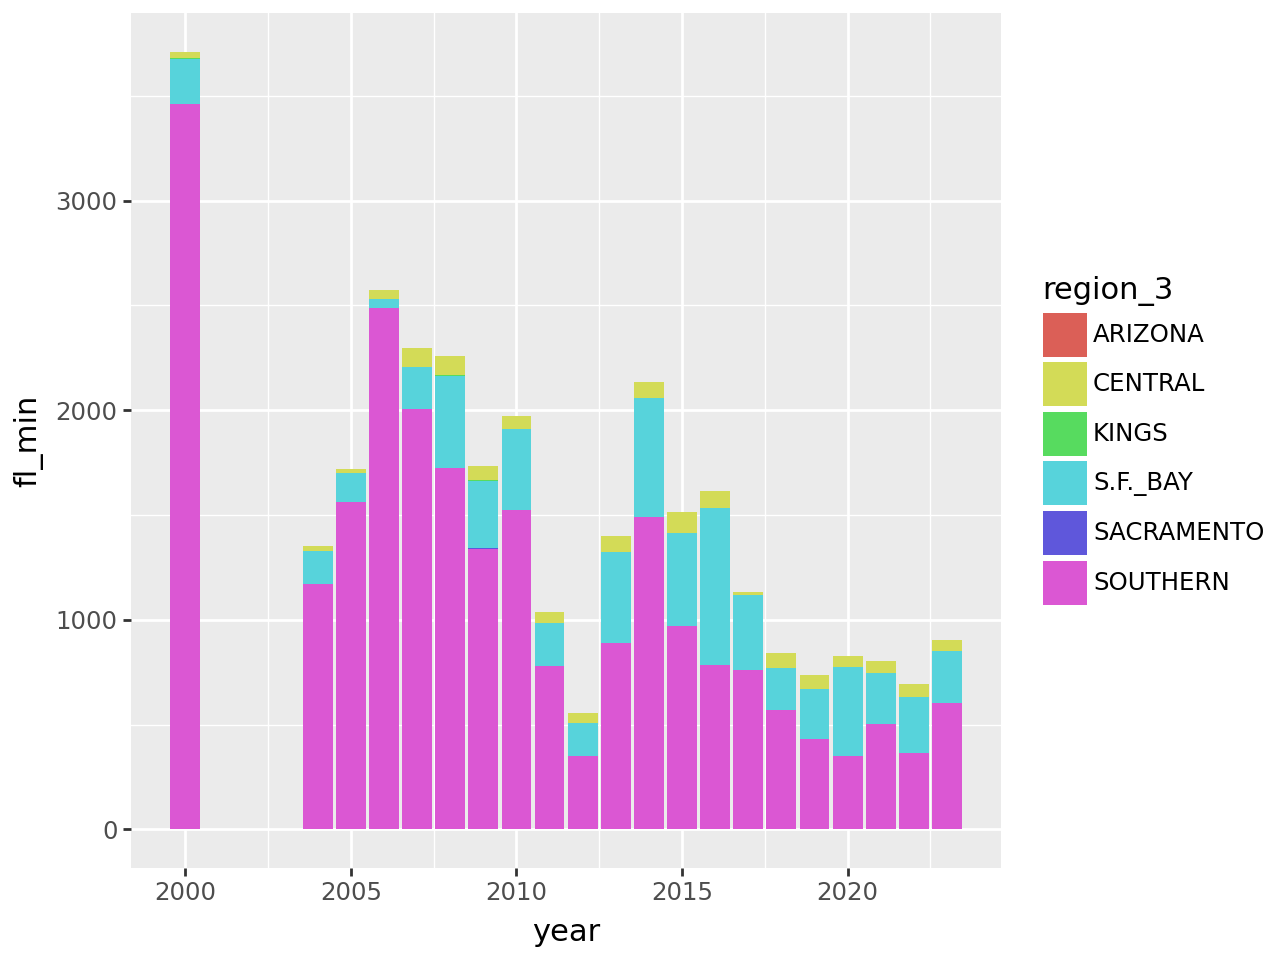

In [17]:
(
    ggplot(terns) +
    aes(x = "year", y = "fl_min", fill = "region_3") +
    geom_bar(stat = "identity")
)

The plot reveals that there are a few extraneous categories in the `region_3`
column: `ARIZONA`, `KINGS`, and `SACRAMENTO`. These might or might not be
erroneous---and it would be good to investigate---but they don't add anything
to this plot, so let's exclude them. Let's also change the **color map**, the
palette of colors used for the categories. These are both properties of the
scale layer for the `fill` aesthetic, so we'll use a `scale_fill_` function.
In particular, since the fill color corresponds to categorical (discrete) data,
we'll use `scale_fill_cmap_d`. We'll also add labels:

In [19]:
(
    ggplot(terns) +
    aes(x = "year", weight = "fl_min", fill = "region_3") +
    geom_bar() +
    scale_fill_cmap_d(limits=["S.F._BAY", "CENTRAL", "SOUTHERN"]) +
    labs(
        title = "California Least Terns: Fledglings",
        x = "Year",
        y = "Minimum Reported Fledglings",
        fill = "Region"
    )
)

ValueError: Invalid RGBA argument: nan

You can read more about setting color maps in Plotnine's [documentation for
this function][p9-cmap]. The plot reveals that the data set is missing
2001-2003 and that overall, fledgling counts seem to be declining in recent
years.

[p9-cmap]: https://plotnine.org/reference/scale_fill_cmap_d.html

**Tip**: The setting `position = "dodge"` instructs `geom_bar` to put the bars
side-by-side rather than stacking them.

### Visualization Design

Designing high-quality visualizations goes beyond just mastering which Python
functions to call. You also need to think carefully about what kind of data you
have and what message you want to convey. This section provides a few
guidelines.

The first step in data visualization is choosing an appropriate kind of plot.
Here are some suggestions (not rules):

| Feature 1   | Feature 2   | Plot                          |
| :---------- | :---------- | :---------------------------- |
| categorical | categorical | bar, dot                      |
| categorical | categorical | bar, dot, mosaic              |
| numerical   |             | box, density, histogram       |
| numerical   | categorical | box, density, ridge           |
| numerical   | numerical   | line, scatter, smooth scatter |

If you want to add a:

* 3rd numerical feature, use it to change point/line size
* 3rd categorical feature, use it to change point/line style
* 4th categorical feature, use side-by-side plots

Once you've selected a plot, here are some rules you should almost always
follow:

* Always add a title and axis labels. These should be descriptive, not variable
  names!
* Specify units after the axis label if the axis has units. For instance,
  "Height (ft)"
* Don't forget that many people are colorblind! Also, plots are often printed
  in black and white. Use point and line styles to distinguish groups; color is
  optional
* Add a legend whenever you've used more than one point or line style
* Always write a few sentences explaining what the plot shows. Don't describe
  the plot, because the reader can just look at it. Instead, explain what they
  can learn from the plot and point out important details that may be
  overlooked
* For side-by-side plots, use the same axis scales for both plots so that
  comparing them is not deceptive

**See Also**: Visualization design is a deep topic, and whole books have been written about
it. One resource where you can learn more is DataLab's [Principles of Data
Visualization][dl-viz] workshop reader.

[dl-viz]: https://ucdavisdatalab.github.io/workshop_data_viz_principles/

## Aggregation & Grouping

"Summarizing Columns" showed how to compute the mean, minimum, and
maximum values of a series. All of these functions **aggregate** the elements
of the series, reducing them to a smaller number of values (usually one).
Polars provides many different aggregation functions, which are [listed in the
documentation][pl-agg].

[pl-agg]: https://docs.pola.rs/api/python/stable/reference/expressions/aggregation.html

For example, to compute the median number of predator-related egg mortalities
across all sites and years:

In [20]:
terns["pred_eggs"].median()

6.5

With the `.select` (or `.with_columns`) method, there are two more ways you can
do this:

In [21]:
terns.select(pl.col("pred_eggs").median())

pred_eggs
f64
6.5


In [22]:
terns.select(pl.median("pred_eggs"))

pred_eggs
f64
6.5


These forms are useful if you want to compute aggregates for multiple columns
at once. For example:

In [23]:
terns.select(
    pl.col(pl.Float64).exclude("year").median()
)

bp_min,bp_max
f64,f64
30.0,38.0


### Grouping

In "Categorical Data", we wrote that the identifying characteristic of
categorical features is that their values are useful for dividing observations
into groups. Now we're actually ready to do that. You can use the `.group_by`
method to group rows in a data frame by one or more columns.


To demonstrate the `.group_by` method, let's compute the median number of nests
by region for the least terns data. We'll use the `region_3` column. After
grouping with `.group_by`, you can use the `.agg` method to compute aggregates
of columns (similar to using `.select`), and Polars will compute a separate
result for each group:

```{code-cell}
terns.group_by("region_3").agg(pl.col("total_nests").median())
```

Like `.select`, the `.agg` method supports computing on multiple columns. For
example, suppose we also want the median number of breeding pairs, and want to
compute the maximum for both features as well. We'll use the `.name.suffix`
method to make sure each column in the result has a unique name:

In [24]:
terns.group_by("region_3").agg(pl.col("total_nests").median())

region_3,total_nests
str,f64
"""KINGS""",1.0
"""SOUTHERN""",64.0
"""SACRAMENTO""",1.0
"""ARIZONA""",3.0
"""CENTRAL""",17.0
"""S.F._BAY""",35.0


Like `.select`, the `.agg` method supports computing on multiple columns. For
example, suppose we also want the median number of breeding pairs, and want to
compute the maximum for both features as well. We'll use the `.name.suffix`
method to make sure each column in the result has a unique name:

In [26]:
cols = ["total_nests", "bp_max"]

terns.group_by("region_3").agg(
    pl.col(cols).median().name.suffix("_median"),
    pl.col(cols).max().name.suffix("_max")
)

region_3,total_nests_median,bp_max_median,total_nests_max,bp_max_max
str,f64,f64,i64,f64
"""S.F._BAY""",35.0,32.0,550,495.0
"""SACRAMENTO""",1.0,1.0,2,1.0
"""ARIZONA""",3.0,2.0,3,2.0
"""KINGS""",1.0,1.0,3,3.0
"""CENTRAL""",17.0,17.0,83,69.0
"""SOUTHERN""",64.0,56.0,1741,1691.0


Some aggregation functions only make sense when used with grouping. One is the
`.first` method, which returns the first row in a group. The `.first` method is
useful when all of the values in a group are the same, and you want to reduce
the data to one row per group.

For example, one way to find all year and climate event combinations present in
the least terns data is to run:

In [27]:
cols = ["year", "event"]

(
    terns.group_by(cols).first()
    .select(cols)
    .sort(cols)
)

year,event
i64,str
2000,"""LA_NINA"""
2004,"""NEUTRAL"""
2005,"""NEUTRAL"""
2006,"""NEUTRAL"""
2007,"""EL_NINO"""
…,…
2019,"""NEUTRAL"""
2020,"""NEUTRAL"""
2021,"""LA_NINA"""


From this result we can conclude that there is only one climate event for each
year in the data set.

For tasks like standardizing features on a per-group basis, it's necessary to
compute aggregates on groups and then map them back to observations. Rather
than using `.group_by` for this, you can use `.select` (or `.with_columns`) and
the `.over` method. For example, to compute mean total nests for each year:

In [28]:
terns.select(
    pl.col("year"),
    pl.col("total_nests").mean().over("year")
)

year,total_nests
i64,f64
2000,182.965517
2000,182.965517
2000,182.965517
2000,182.965517
2000,182.965517
…,…
2023,95.918919
2023,95.918919
2023,95.918919


This approach returns a data frame with the same number of rows as the original
data frame, unlike the `.group_by` and `.agg` approach, which returns a data
frame with the same number of rows as there are groups.

**Tip**: Use `.select` (or `.with_columns`) and `.over` if you want to compute grouped
aggregates to use in further computations on the data frame. Use `.group_by`
and `.agg` if you only want to compute grouped aggregates (for example, as a
summary, to make a visualization, or to use in further computations that are
not on the data frame).